In [1]:
import pandas as pd
import numpy as np
import duckdb
import matplotlib.pyplot as plt
import seaborn as sns

print("Core libraries imported successfully")

Core libraries imported successfully


In [3]:
from pathlib import Path

# Project root
PROJECT_ROOT = Path.cwd().parent

# Raw dataset path
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "PS_20174392719_1491204439457_log.csv"

print("Dataset path:")
print(DATA_PATH)

print("\nFile exists:", DATA_PATH.exists())

if DATA_PATH.exists():
    print("File size (MB):", round(DATA_PATH.stat().st_size / (1024 ** 2), 2))


Dataset path:
/Users/binodkumar/Documents/financial-fraud-risk-intelligence/data/raw/PS_20174392719_1491204439457_log.csv

File exists: True
File size (MB): 470.67


In [4]:
# Inspect the CSV structure using DuckDB

column_info = duckdb.sql(f"""
    DESCRIBE
    SELECT *
    FROM read_csv_auto('{DATA_PATH}')
""").df()

column_info

,column_name,column_type,null,key,default,extra
0,step,BIGINT,YES,None,None,None
1,type,VARCHAR,YES,None,None,None
2,amount,DOUBLE,YES,None,None,None
3,nameOrig,VARCHAR,YES,None,None,None
4,oldbalanceOrg,DOUBLE,YES,None,None,None
5,newbalanceOrig,DOUBLE,YES,None,None,None
6,nameDest,VARCHAR,YES,None,None,None
7,oldbalanceDest,DOUBLE,YES,None,None,None
8,newbalanceDest,DOUBLE,YES,None,None,None
9,isFraud,BIGINT,YES,None,None,None


In [5]:
# Exact dataset dimensions

row_count = duckdb.sql(f"""
    SELECT COUNT(*) AS total_rows
    FROM read_csv_auto('{DATA_PATH}')
""").fetchone()[0]

column_count = len(column_info)

print(f"Total transactions: {row_count:,}")
print(f"Total columns: {column_count}")

Total transactions: 6,362,620
Total columns: 11


In [6]:
# Missing-value audit

missing_data = duckdb.sql(f"""
    SELECT
        COUNT(*) AS total_rows,
        COUNT(*) - COUNT(step) AS step_missing,
        COUNT(*) - COUNT(type) AS type_missing,
        COUNT(*) - COUNT(amount) AS amount_missing,
        COUNT(*) - COUNT(nameOrig) AS nameOrig_missing,
        COUNT(*) - COUNT(oldbalanceOrg) AS oldbalanceOrg_missing,
        COUNT(*) - COUNT(newbalanceOrig) AS newbalanceOrig_missing,
        COUNT(*) - COUNT(nameDest) AS nameDest_missing,
        COUNT(*) - COUNT(oldbalanceDest) AS oldbalanceDest_missing,
        COUNT(*) - COUNT(newbalanceDest) AS newbalanceDest_missing,
        COUNT(*) - COUNT(isFraud) AS isFraud_missing,
        COUNT(*) - COUNT(isFlaggedFraud) AS isFlaggedFraud_missing
    FROM read_csv_auto('{DATA_PATH}')
""").df()

missing_data.T

,0
total_rows,6362620
step_missing,0
type_missing,0
amount_missing,0
nameOrig_missing,0
oldbalanceOrg_missing,0
newbalanceOrig_missing,0
nameDest_missing,0
oldbalanceDest_missing,0
newbalanceDest_missing,0


In [7]:
# Duplicate row audit

duplicate_count = duckdb.sql(f"""
    SELECT
        COUNT(*) - COUNT(DISTINCT (
            step,
            type,
            amount,
            nameOrig,
            oldbalanceOrg,
            newbalanceOrig,
            nameDest,
            oldbalanceDest,
            newbalanceDest,
            isFraud,
            isFlaggedFraud
        )) AS duplicate_rows
    FROM read_csv_auto('{DATA_PATH}')
""").fetchone()[0]

print(f"Exact duplicate rows: {duplicate_count:,}")

Exact duplicate rows: 0


In [8]:
# Fraud vs legitimate transaction distribution

fraud_distribution = duckdb.sql(f"""
    SELECT
        isFraud,
        COUNT(*) AS transaction_count,
        ROUND(
            COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (),
            4
        ) AS percentage
    FROM read_csv_auto('{DATA_PATH}')
    GROUP BY isFraud
    ORDER BY isFraud
""").df()

fraud_distribution

,isFraud,transaction_count,percentage
0,0,6354407,99.8709
1,1,8213,0.1291


In [9]:
# Transaction type distribution

transaction_types = duckdb.sql(f"""
    SELECT
        type,
        COUNT(*) AS transaction_count,
        ROUND(
            COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (),
            2
        ) AS percentage
    FROM read_csv_auto('{DATA_PATH}')
    GROUP BY type
    ORDER BY transaction_count DESC
""").df()

transaction_types

,type,transaction_count,percentage
0,CASH_OUT,2237500,35.17
1,PAYMENT,2151495,33.81
2,CASH_IN,1399284,21.99
3,TRANSFER,532909,8.38
4,DEBIT,41432,0.65


In [10]:
# Fraud distribution by transaction type

fraud_by_type = duckdb.sql(f"""
    SELECT
        type,
        COUNT(*) AS total_transactions,
        SUM(isFraud) AS fraudulent_transactions,
        ROUND(
            SUM(isFraud) * 100.0 / COUNT(*),
            4
        ) AS fraud_rate_pct
    FROM read_csv_auto('{DATA_PATH}')
    GROUP BY type
    ORDER BY fraud_rate_pct DESC
""").df()

fraud_by_type

,type,total_transactions,fraudulent_transactions,fraud_rate_pct
0,TRANSFER,532909,4097.0,0.7688
1,CASH_OUT,2237500,4116.0,0.1840
2,CASH_IN,1399284,0.0,0.0000
3,PAYMENT,2151495,0.0,0.0000
4,DEBIT,41432,0.0,0.0000


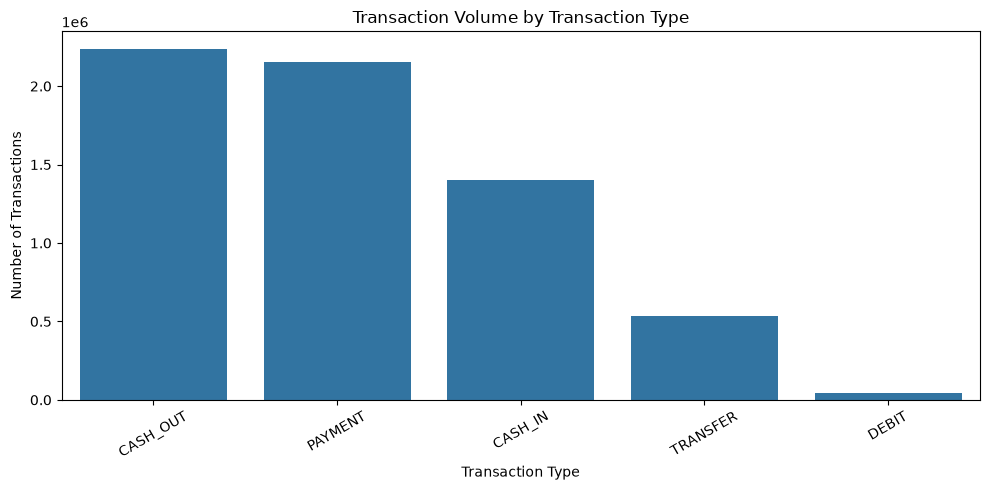

In [13]:
# Transaction volume by type

plt.figure(figsize=(10, 5))

sns.barplot(
    data=transaction_types,
    x="type",
    y="transaction_count"
)

plt.title("Transaction Volume by Transaction Type")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

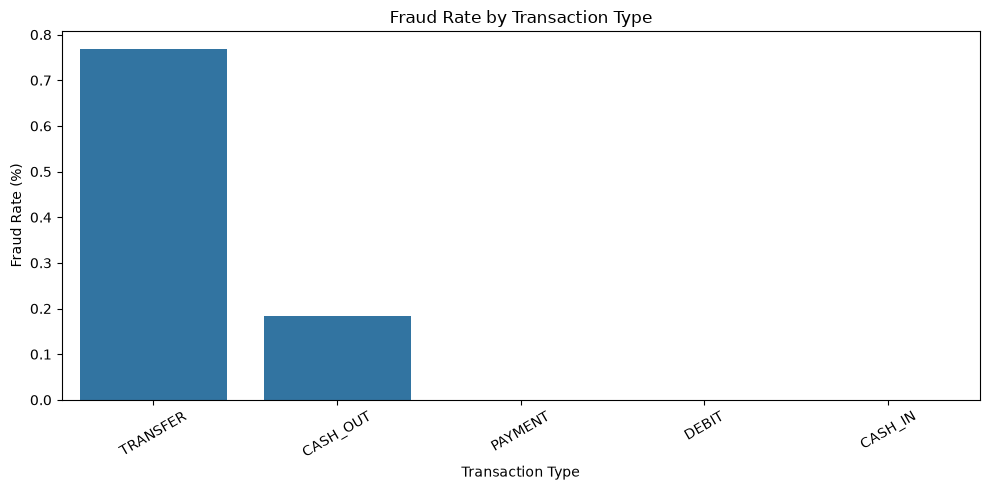

In [14]:
# Fraud rate by transaction type

plt.figure(figsize=(10, 5))

sns.barplot(
    data=fraud_by_type,
    x="type",
    y="fraud_rate_pct"
)

plt.title("Fraud Rate by Transaction Type")
plt.xlabel("Transaction Type")
plt.ylabel("Fraud Rate (%)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [15]:
# Transaction amount profile

amount_profile = duckdb.sql(f"""
    SELECT
        isFraud,
        COUNT(*) AS transaction_count,
        ROUND(AVG(amount), 2) AS average_amount,
        ROUND(MEDIAN(amount), 2) AS median_amount,
        ROUND(MIN(amount), 2) AS minimum_amount,
        ROUND(MAX(amount), 2) AS maximum_amount,
        ROUND(SUM(amount), 2) AS total_amount
    FROM read_csv_auto('{DATA_PATH}')
    GROUP BY isFraud
    ORDER BY isFraud
""").df()

amount_profile

,isFraud,transaction_count,average_amount,median_amount,minimum_amount,maximum_amount,total_amount
0,0,6354407,178197.04,74684.72,0.01,92445516.64,1.132337e+12
1,1,8213,1467967.30,441423.44,0.00,10000000.00,1.205642e+10


In [16]:
# Amount distribution by fraud status

amount_summary = duckdb.sql(f"""
    SELECT
        CASE
            WHEN isFraud = 1 THEN 'Fraud'
            ELSE 'Legitimate'
        END AS fraud_status,
        amount
    FROM read_csv_auto('{DATA_PATH}')
""").df()

amount_summary.head()

,fraud_status,amount
0,Legitimate,9839.64
1,Legitimate,1864.28
2,Fraud,181.00
3,Fraud,181.00
4,Legitimate,11668.14


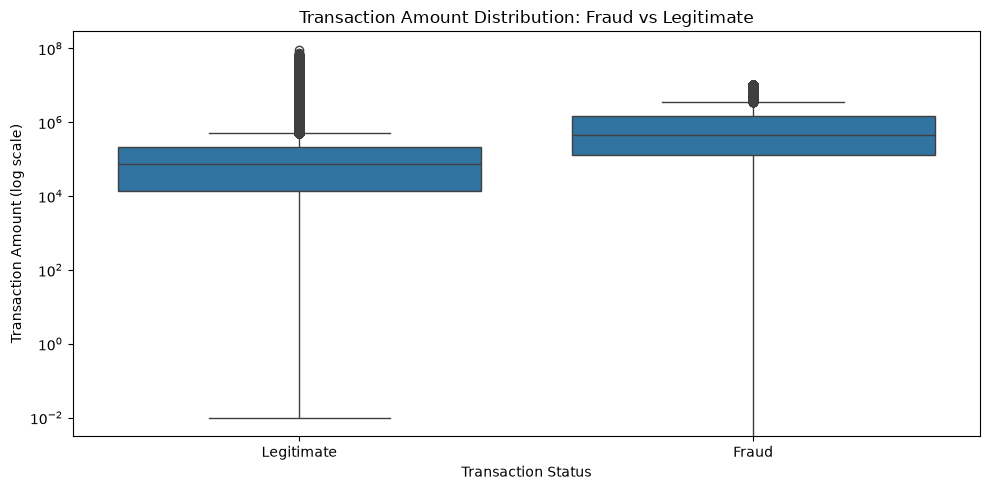

In [17]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=amount_summary,
    x="fraud_status",
    y="amount"
)

plt.yscale("log")
plt.title("Transaction Amount Distribution: Fraud vs Legitimate")
plt.xlabel("Transaction Status")
plt.ylabel("Transaction Amount (log scale)")
plt.tight_layout()
plt.show()

In [18]:
# Transaction amount profile

amount_profile = duckdb.sql(f"""
    SELECT
        isFraud,
        COUNT(*) AS transaction_count,
        ROUND(AVG(amount), 2) AS average_amount,
        ROUND(MEDIAN(amount), 2) AS median_amount,
        ROUND(MIN(amount), 2) AS minimum_amount,
        ROUND(MAX(amount), 2) AS maximum_amount,
        ROUND(SUM(amount), 2) AS total_amount
    FROM read_csv_auto('{DATA_PATH}')
    GROUP BY isFraud
    ORDER BY isFraud
""").df()

amount_profile

,isFraud,transaction_count,average_amount,median_amount,minimum_amount,maximum_amount,total_amount
0,0,6354407,178197.04,74684.72,0.01,92445516.64,1.132337e+12
1,1,8213,1467967.30,441423.44,0.00,10000000.00,1.205642e+10


In [19]:
# Amount distribution by fraud status

amount_summary = duckdb.sql(f"""
    SELECT
        CASE
            WHEN isFraud = 1 THEN 'Fraud'
            ELSE 'Legitimate'
        END AS fraud_status,
        amount
    FROM read_csv_auto('{DATA_PATH}')
""").df()

amount_summary.head()

,fraud_status,amount
0,Legitimate,9839.64
1,Legitimate,1864.28
2,Fraud,181.00
3,Fraud,181.00
4,Legitimate,11668.14


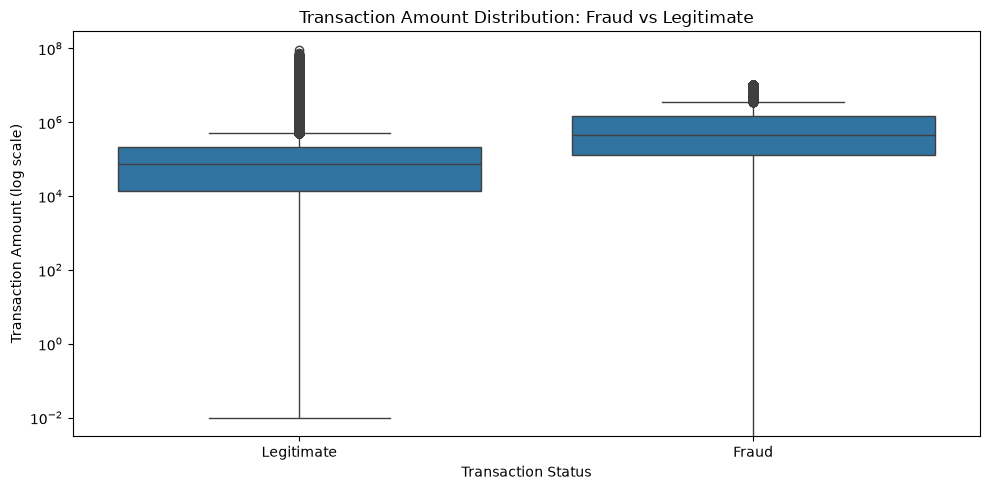

In [20]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=amount_summary,
    x="fraud_status",
    y="amount"
)

plt.yscale("log")
plt.title("Transaction Amount Distribution: Fraud vs Legitimate")
plt.xlabel("Transaction Status")
plt.ylabel("Transaction Amount (log scale)")
plt.tight_layout()
plt.show()

In [21]:
# Balance consistency audit

balance_audit = duckdb.sql(f"""
    SELECT
        type,
        COUNT(*) AS transactions,

        SUM(
            CASE
                WHEN ABS(oldbalanceOrg - amount - newbalanceOrig) > 0.01
                THEN 1 ELSE 0
            END
        ) AS origin_balance_mismatch,

        SUM(
            CASE
                WHEN ABS(oldbalanceDest + amount - newbalanceDest) > 0.01
                THEN 1 ELSE 0
            END
        ) AS destination_balance_mismatch

    FROM read_csv_auto('{DATA_PATH}')
    GROUP BY type
    ORDER BY transactions DESC
""").df()

balance_audit

,type,transactions,origin_balance_mismatch,destination_balance_mismatch
0,CASH_OUT,2237500,1991269.0,507426.0
1,PAYMENT,2151495,1165894.0,2151495.0
2,CASH_IN,1399284,1399284.0,1399284.0
3,TRANSFER,532909,508782.0,120811.0
4,DEBIT,41432,12462.0,9631.0


In [22]:
# Calculate balance changes

balance_changes = duckdb.sql(f"""
    SELECT
        type,

        ROUND(AVG(oldbalanceOrg - newbalanceOrig), 2)
            AS avg_origin_balance_change,

        ROUND(AVG(newbalanceDest - oldbalanceDest), 2)
            AS avg_destination_balance_change,

        ROUND(AVG(amount), 2)
            AS avg_transaction_amount

    FROM read_csv_auto('{DATA_PATH}')
    GROUP BY type
    ORDER BY type
""").df()

balance_changes

,type,avg_origin_balance_change,avg_destination_balance_change,avg_transaction_amount
0,CASH_IN,-168915.20,-120813.41,168920.24
1,CASH_OUT,28549.61,193568.18,176273.96
2,DEBIT,3485.69,19867.70,5483.67
3,PAYMENT,6378.94,0.00,13057.60
4,TRANSFER,44153.70,986961.11,910647.01


In [23]:
# Compare balance behavior between fraudulent and legitimate transactions

fraud_balance = duckdb.sql(f"""
    SELECT
        isFraud,

        ROUND(AVG(amount), 2) AS avg_amount,

        ROUND(AVG(oldbalanceOrg), 2) AS avg_origin_balance_before,

        ROUND(AVG(newbalanceOrig), 2) AS avg_origin_balance_after,

        ROUND(AVG(oldbalanceDest), 2) AS avg_destination_balance_before,

        ROUND(AVG(newbalanceDest), 2) AS avg_destination_balance_after

    FROM read_csv_auto('{DATA_PATH}')
    GROUP BY isFraud
    ORDER BY isFraud
""").df()

fraud_balance

,isFraud,avg_amount,avg_origin_balance_before,avg_origin_balance_after,avg_destination_balance_before,avg_destination_balance_after
0,0,178197.04,832828.71,855970.23,1101420.87,1224925.68
1,1,1467967.30,1649667.61,192392.63,544249.62,1279707.62


In [24]:
# Account-level overview

account_overview = duckdb.sql(f"""
    SELECT
        COUNT(DISTINCT nameOrig) AS unique_origin_accounts,
        COUNT(DISTINCT nameDest) AS unique_destination_accounts
    FROM read_csv_auto('{DATA_PATH}')
""").df()

account_overview

,unique_origin_accounts,unique_destination_accounts
0,6353307,2722362


In [25]:
# Origin account transaction frequency

origin_activity = duckdb.sql(f"""
    SELECT
        nameOrig,
        COUNT(*) AS transaction_count,
        SUM(isFraud) AS fraud_count,
        ROUND(SUM(amount), 2) AS total_transaction_amount
    FROM read_csv_auto('{DATA_PATH}')
    GROUP BY nameOrig
    ORDER BY transaction_count DESC
    LIMIT 20
""").df()

origin_activity

,nameOrig,transaction_count,fraud_count,total_transaction_amount
0,C1065307291,3,0.0,113479.28
1,C1999539787,3,0.0,290555.01
2,C1832548028,3,0.0,313665.83
3,C1530544995,3,0.0,490535.09
4,C2051359467,3,0.0,89313.36
5,C545315117,3,0.0,2485461.64
6,C363736674,3,0.0,68726.33
7,C1902386530,3,0.0,763712.79
8,C1677795071,3,0.0,244735.38
9,C1784010646,3,0.0,436700.25


In [26]:
# Origin accounts associated with fraudulent transactions

fraud_origin_accounts = duckdb.sql(f"""
    SELECT
        nameOrig,
        COUNT(*) AS total_transactions,
        SUM(isFraud) AS fraud_transactions,
        ROUND(SUM(amount), 2) AS total_amount
    FROM read_csv_auto('{DATA_PATH}')
    WHERE isFraud = 1
    GROUP BY nameOrig
    ORDER BY fraud_transactions DESC, total_amount DESC
    LIMIT 20
""").df()

fraud_origin_accounts

,nameOrig,total_transactions,fraud_transactions,total_amount
0,C829777561,1,1.0,10000000.0
1,C997532070,1,1.0,10000000.0
2,C2068007279,1,1.0,10000000.0
3,C1066838925,1,1.0,10000000.0
4,C298387535,1,1.0,10000000.0
5,C714385617,1,1.0,10000000.0
6,C217654973,1,1.0,10000000.0
7,C1162717928,1,1.0,10000000.0
8,C1299526002,1,1.0,10000000.0
9,C327855497,1,1.0,10000000.0


In [27]:
# Unique accounts associated with fraud

fraud_account_summary = duckdb.sql(f"""
    SELECT
        COUNT(DISTINCT nameOrig) AS origin_accounts_with_fraud,
        COUNT(DISTINCT nameDest) AS destination_accounts_in_fraud
    FROM read_csv_auto('{DATA_PATH}')
    WHERE isFraud = 1
""").df()

fraud_account_summary

,origin_accounts_with_fraud,destination_accounts_in_fraud
0,8213,8169


In [28]:
# Distribution of transactions per origin account

origin_frequency = duckdb.sql(f"""
    SELECT
        nameOrig,
        COUNT(*) AS transaction_count
    FROM read_csv_auto('{DATA_PATH}')
    GROUP BY nameOrig
""").df()

origin_frequency.describe()

,transaction_count
count,6.353307e+06
mean,1.001466e+00
std,3.832002e-02
min,1.000000e+00
25%,1.000000e+00
50%,1.000000e+00
75%,1.000000e+00
max,3.000000e+00


In [29]:
# Temporal coverage of the dataset

time_range = duckdb.sql(f"""
    SELECT
        MIN(step) AS first_step,
        MAX(step) AS last_step,
        COUNT(DISTINCT step) AS unique_steps
    FROM read_csv_auto('{DATA_PATH}')
""").df()

time_range

,first_step,last_step,unique_steps
0,1,743,743


In [30]:
# Transaction and fraud activity over time

time_activity = duckdb.sql(f"""
    SELECT
        step,
        COUNT(*) AS total_transactions,
        SUM(isFraud) AS fraudulent_transactions,
        ROUND(
            SUM(isFraud) * 100.0 / COUNT(*),
            4
        ) AS fraud_rate_pct,
        ROUND(SUM(amount), 2) AS total_transaction_amount
    FROM read_csv_auto('{DATA_PATH}')
    GROUP BY step
    ORDER BY step
""").df()

time_activity.head(10)

,step,total_transactions,fraudulent_transactions,fraud_rate_pct,total_transaction_amount
0,1,2708,16.0,0.5908,2.854292e+08
1,2,1014,8.0,0.7890,8.592160e+07
2,3,552,4.0,0.7246,4.329388e+07
3,4,565,10.0,1.7699,7.291003e+07
4,5,665,6.0,0.9023,4.554809e+07
5,6,1660,22.0,1.3253,1.643106e+08
6,7,6837,12.0,0.1755,8.329308e+08
7,8,21097,12.0,0.0569,3.439602e+09
8,9,37628,19.0,0.0505,7.008379e+09
9,10,35991,11.0,0.0306,7.124215e+09


In [31]:
# Steps with the highest number of fraudulent transactions

top_fraud_steps = time_activity.sort_values(
    "fraudulent_transactions",
    ascending=False
).head(20)

top_fraud_steps

,step,total_transactions,fraudulent_transactions,fraud_rate_pct,total_transaction_amount
211,212,34047,40.0,0.1175,4.386135e+09
522,523,30,30.0,100.0000,6.954014e+07
386,387,28,28.0,100.0000,1.472376e+08
500,501,28,28.0,100.0000,7.961467e+07
729,730,28,28.0,100.0000,1.150034e+08
424,425,28,28.0,100.0000,1.102985e+08
248,249,23209,28.0,0.1206,3.792801e+09
397,398,26656,26.0,0.0975,5.024591e+09
159,160,27765,26.0,0.0936,4.657391e+09
405,406,12023,24.0,0.1996,1.737108e+09


In [32]:
# Steps with the highest fraud rate

top_fraud_rate_steps = time_activity.sort_values(
    "fraud_rate_pct",
    ascending=False
).head(20)

top_fraud_rate_steps

,step,total_transactions,fraudulent_transactions,fraud_rate_pct,total_transaction_amount
742,743,8,8.0,100.0,17519825.50
532,533,12,12.0,100.0,13069443.86
268,269,14,14.0,100.0,30786900.72
267,268,6,6.0,100.0,8090414.72
567,568,14,14.0,100.0,21012595.98
571,572,18,18.0,100.0,11261178.00
574,575,8,8.0,100.0,4362409.58
578,579,12,12.0,100.0,13391113.62
580,581,10,10.0,100.0,8109043.62
582,583,16,16.0,100.0,12437199.90


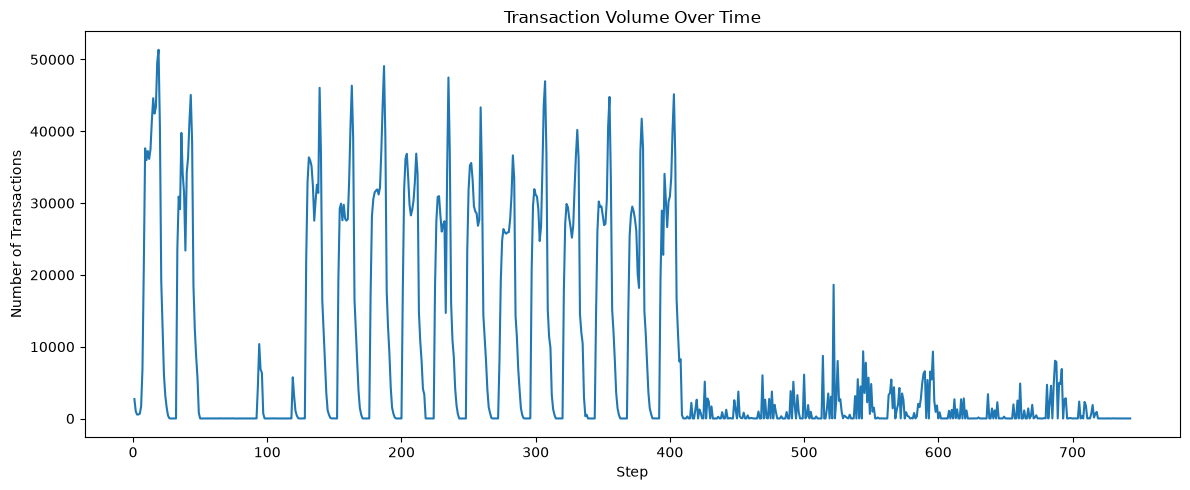

In [33]:
# Transaction volume over time

plt.figure(figsize=(12, 5))

plt.plot(
    time_activity["step"],
    time_activity["total_transactions"]
)

plt.title("Transaction Volume Over Time")
plt.xlabel("Step")
plt.ylabel("Number of Transactions")
plt.tight_layout()
plt.show()

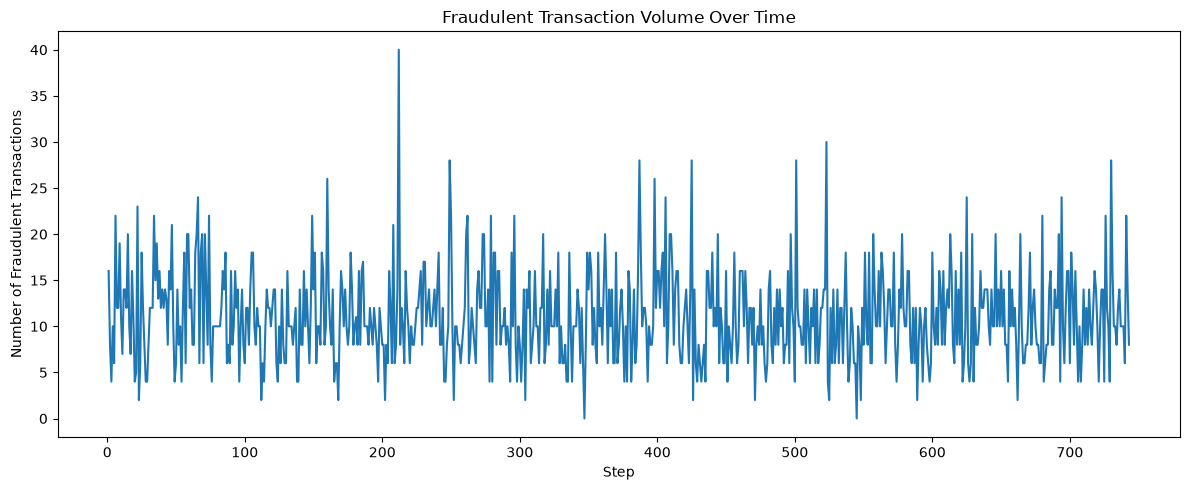

In [34]:
# Fraudulent transaction volume over time

plt.figure(figsize=(12, 5))

plt.plot(
    time_activity["step"],
    time_activity["fraudulent_transactions"]
)

plt.title("Fraudulent Transaction Volume Over Time")
plt.xlabel("Step")
plt.ylabel("Number of Fraudulent Transactions")
plt.tight_layout()
plt.show()

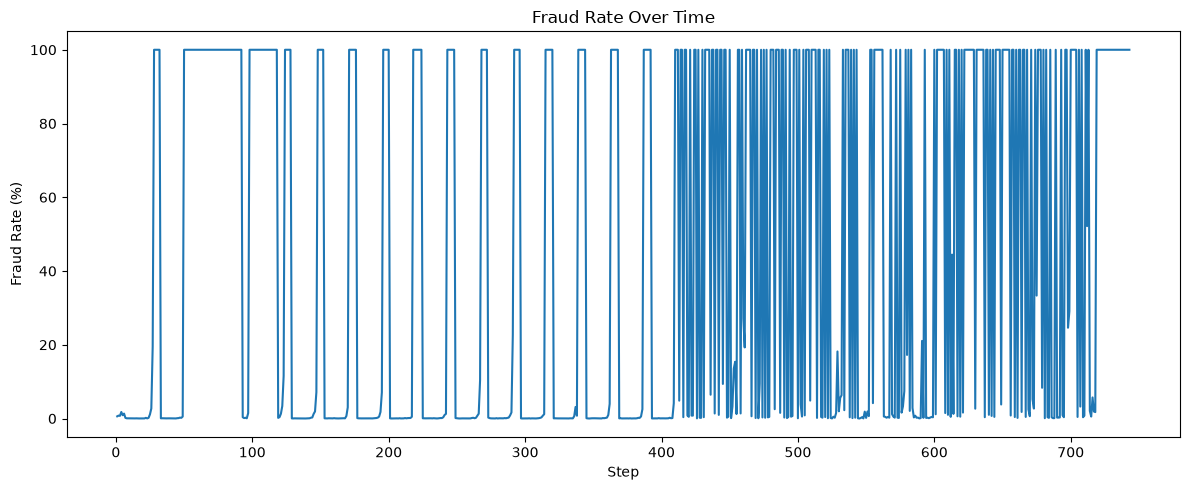

In [35]:
# Fraud rate over time

plt.figure(figsize=(12, 5))

plt.plot(
    time_activity["step"],
    time_activity["fraud_rate_pct"]
)

plt.title("Fraud Rate Over Time")
plt.xlabel("Step")
plt.ylabel("Fraud Rate (%)")
plt.tight_layout()
plt.show()

In [36]:
# Origin account transaction velocity

origin_velocity = duckdb.sql(f"""
    SELECT
        nameOrig,
        COUNT(*) AS transaction_count,
        COUNT(DISTINCT step) AS active_steps,
        ROUND(
            COUNT(*) * 1.0 / NULLIF(COUNT(DISTINCT step), 0),
            2
        ) AS transactions_per_active_step,
        SUM(isFraud) AS fraud_count
    FROM read_csv_auto('{DATA_PATH}')
    GROUP BY nameOrig
""").df()

origin_velocity.head()

,nameOrig,transaction_count,active_steps,transactions_per_active_step,fraud_count
0,C1670993182,1,1,1.0,0.0
1,C1528834618,1,1,1.0,0.0
2,C885910946,1,1,1.0,0.0
3,C855700733,1,1,1.0,0.0
4,C1033348658,1,1,1.0,0.0


In [37]:
# Highest-velocity origin accounts

high_velocity_accounts = origin_velocity.sort_values(
    "transactions_per_active_step",
    ascending=False
).head(20)

high_velocity_accounts

,nameOrig,transaction_count,active_steps,transactions_per_active_step,fraud_count
5274750,C1406729820,2,1,2.0,0.0
2808220,C424465218,2,1,2.0,0.0
1850333,C4295411,2,1,2.0,0.0
834715,C1965131583,2,1,2.0,0.0
4391336,C1875088824,2,1,2.0,0.0
688311,C586573796,2,1,2.0,0.0
5717174,C1936767134,2,1,2.0,0.0
1564471,C570148238,2,1,2.0,0.0
5420549,C304901420,2,1,2.0,0.0
5040549,C1828219334,2,1,2.0,0.0


In [38]:
# Balance-drain behavior

balance_drain = duckdb.sql(f"""
    SELECT
        isFraud,
        COUNT(*) AS transactions,
        SUM(
            CASE
                WHEN newbalanceOrig = 0
                THEN 1 ELSE 0
            END
        ) AS zero_balance_transactions,
        ROUND(
            SUM(
                CASE
                    WHEN newbalanceOrig = 0
                    THEN 1 ELSE 0
                END
            ) * 100.0 / COUNT(*),
            2
        ) AS zero_balance_pct
    FROM read_csv_auto('{DATA_PATH}')
    GROUP BY isFraud
    ORDER BY isFraud
""").df()

balance_drain

,isFraud,transactions,zero_balance_transactions,zero_balance_pct
0,0,6354407,3601513.0,56.68
1,1,8213,8053.0,98.05


In [39]:
# Transaction amount relative to origin balance

amount_balance_ratio = duckdb.sql(f"""
    SELECT
        isFraud,

        ROUND(
            AVG(
                CASE
                    WHEN oldbalanceOrg > 0
                    THEN amount / oldbalanceOrg
                    ELSE NULL
                END
            ),
            4
        ) AS avg_amount_balance_ratio,

        ROUND(
            MEDIAN(
                CASE
                    WHEN oldbalanceOrg > 0
                    THEN amount / oldbalanceOrg
                    ELSE NULL
                END
            ),
            4
        ) AS median_amount_balance_ratio,

        ROUND(
            SUM(
                CASE
                    WHEN oldbalanceOrg > 0
                         AND amount / oldbalanceOrg >= 0.90
                    THEN 1 ELSE 0
                END
            ) * 100.0 / COUNT(*),
            2
        ) AS pct_transactions_over_90pct_balance

    FROM read_csv_auto('{DATA_PATH}')
    GROUP BY isFraud
    ORDER BY isFraud
""").df()

amount_balance_ratio

,isFraud,avg_amount_balance_ratio,median_amount_balance_ratio,pct_transactions_over_90pct_balance
0,0,122.2727,0.7347,31.91
1,1,0.9988,1.0000,97.84


In [40]:
# Transactions exceeding the recorded origin balance

balance_violation = duckdb.sql(f"""
    SELECT
        isFraud,
        COUNT(*) AS transactions,
        SUM(
            CASE
                WHEN amount > oldbalanceOrg
                THEN 1 ELSE 0
            END
        ) AS amount_exceeds_balance,
        ROUND(
            SUM(
                CASE
                    WHEN amount > oldbalanceOrg
                    THEN 1 ELSE 0
                END
            ) * 100.0 / COUNT(*),
            4
        ) AS violation_pct
    FROM read_csv_auto('{DATA_PATH}')
    GROUP BY isFraud
    ORDER BY isFraud
""").df()

balance_violation

,isFraud,transactions,amount_exceeds_balance,violation_pct
0,0,6354407,4079051.0,64.1925
1,1,8213,29.0,0.3531


In [41]:
# Fraud and amount behavior by transaction type

type_risk_profile = duckdb.sql(f"""
    SELECT
        type,

        COUNT(*) AS total_transactions,

        SUM(isFraud) AS fraud_transactions,

        ROUND(
            SUM(isFraud) * 100.0 / COUNT(*),
            4
        ) AS fraud_rate_pct,

        ROUND(AVG(amount), 2) AS avg_amount,

        ROUND(
            AVG(
                CASE
                    WHEN isFraud = 1
                    THEN amount
                    ELSE NULL
                END
            ),
            2
        ) AS avg_fraud_amount

    FROM read_csv_auto('{DATA_PATH}')
    GROUP BY type
    ORDER BY fraud_rate_pct DESC
""").df()

type_risk_profile

,type,total_transactions,fraud_transactions,fraud_rate_pct,avg_amount,avg_fraud_amount
0,TRANSFER,532909,4097.0,0.7688,910647.01,1480891.67
1,CASH_OUT,2237500,4116.0,0.1840,176273.96,1455102.59
2,CASH_IN,1399284,0.0,0.0000,168920.24,NaN
3,PAYMENT,2151495,0.0,0.0000,13057.60,NaN
4,DEBIT,41432,0.0,0.0000,5483.67,NaN


In [42]:
# Existing fraud flag vs actual fraud

flag_performance = duckdb.sql(f"""
    SELECT
        isFlaggedFraud,
        COUNT(*) AS transactions,
        SUM(isFraud) AS actual_fraud,
        ROUND(
            SUM(isFraud) * 100.0 / COUNT(*),
            4
        ) AS actual_fraud_rate_pct
    FROM read_csv_auto('{DATA_PATH}')
    GROUP BY isFlaggedFraud
    ORDER BY isFlaggedFraud
""").df()

flag_performance

,isFlaggedFraud,transactions,actual_fraud,actual_fraud_rate_pct
0,0,6362604,8197.0,0.1288
1,1,16,16.0,100.0000


In [43]:
# Candidate risk signal summary

risk_signal_summary = duckdb.sql(f"""
    SELECT
        isFraud,

        COUNT(*) AS transactions,

        ROUND(AVG(amount), 2) AS avg_amount,

        ROUND(
            AVG(
                CASE
                    WHEN oldbalanceOrg > 0
                    THEN amount / oldbalanceOrg
                    ELSE NULL
                END
            ),
            4
        ) AS avg_amount_balance_ratio,

        ROUND(
            SUM(
                CASE
                    WHEN newbalanceOrig = 0
                    THEN 1 ELSE 0
                END
            ) * 100.0 / COUNT(*),
            2
        ) AS pct_zero_origin_balance,

        ROUND(
            SUM(
                CASE
                    WHEN amount > oldbalanceOrg
                    THEN 1 ELSE 0
                END
            ) * 100.0 / COUNT(*),
            2
        ) AS pct_amount_over_origin_balance

    FROM read_csv_auto('{DATA_PATH}')
    GROUP BY isFraud
    ORDER BY isFraud
""").df()

risk_signal_summary

,isFraud,transactions,avg_amount,avg_amount_balance_ratio,pct_zero_origin_balance,pct_amount_over_origin_balance
0,0,6354407,178197.04,122.2727,56.68,64.19
1,1,8213,1467967.30,0.9988,98.05,0.35
